In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np


In [21]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Loading the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Outputing the shapes of the dataset
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)


(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [22]:
# Performing Data transformations: normalize pixel values to range [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # CIFAR-10 mean and stddev
])

# Loading CIFAR-10 dataset
train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Spliting training data into training and validation sets
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_data, val_data = random_split(train_data, [train_size, val_size])

# Creating data loaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


In [23]:
import torch

# Checking if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Moving the model to the specified device
model = CNNModel().to(device)


Using device: cpu


In [24]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Epoch 1/10.. Training loss: 1.3338.. Validation loss: 1.0864
Epoch 2/10.. Training loss: 0.9364.. Validation loss: 0.9115
Epoch 3/10.. Training loss: 0.7369.. Validation loss: 0.8352
Epoch 4/10.. Training loss: 0.5658.. Validation loss: 0.8118
Epoch 5/10.. Training loss: 0.4027.. Validation loss: 0.8836
Epoch 6/10.. Training loss: 0.2506.. Validation loss: 0.9681
Epoch 7/10.. Training loss: 0.1471.. Validation loss: 1.1305
Epoch 8/10.. Training loss: 0.0880.. Validation loss: 1.2526
Epoch 9/10.. Training loss: 0.0756.. Validation loss: 1.3708
Epoch 10/10.. Training loss: 0.0638.. Validation loss: 1.4963


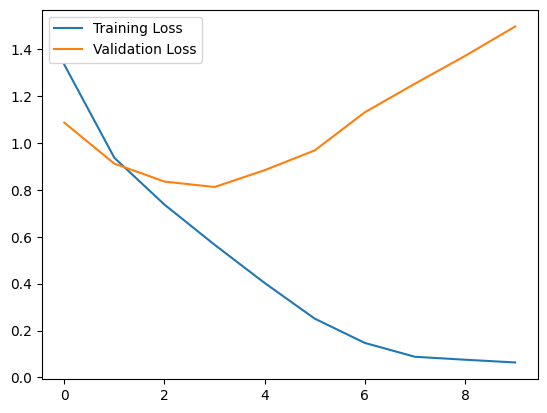

In [25]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_loss = []
    val_loss = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Zeroing the parameter gradients
            optimizer.zero_grad()
            
            # Forwarding pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        # Calculating average loss for this epoch
        train_loss.append(running_loss / len(train_loader))

        # Validating the model
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
        
        val_loss.append(val_running_loss / len(val_loader))

        print(f'Epoch {epoch+1}/{epochs}.. Training loss: {train_loss[-1]:.4f}.. Validation loss: {val_loss[-1]:.4f}')

    return train_loss, val_loss

# Training the model
train_loss, val_loss = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)

# Plot training and validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.show()


In [26]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Test Accuracy: {100 * correct / total:.2f}%')

# Testing the model
test_model(model, test_loader)


Test Accuracy: 70.84%


In [27]:
torch.save(model.state_dict(), 'model.pth')
